In [1]:
import numpy as np
import pandas as pd

In [2]:
print("Hello")

Hello


In [5]:
df = pd.read_csv("C:/Users/praty/OneDrive/Desktop/Machine-Learning/placement-dataset.csv")

In [6]:
df.head()

,city,cgpa,iq,placement
0,New York,6.8,123.0,1
1,Los Angeles,5.9,106.0,0
2,Chicago,NaN,121.0,0
3,New York,7.4,132.0,1
4,Los Angeles,5.8,142.0,0


In [7]:
df = df.iloc[:,1:]

In [8]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,NaN,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [10]:
df = df.dropna()

In [11]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
3,7.4,132.0,1
4,5.8,142.0,0
5,7.1,48.0,1


In [12]:
df.info()

<class 'pandas.DataFrame'>
Index: 88 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       88 non-null     float64
 1   iq         88 non-null     float64
 2   placement  88 non-null     int64  
dtypes: float64(2), int64(1)
memory usage: 2.8 KB


In [13]:
import matplotlib.pyplot as plt

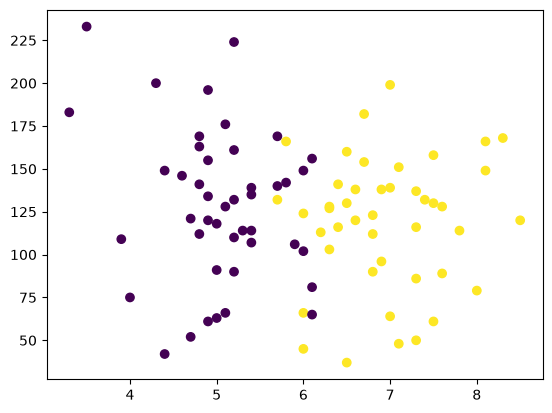

In [17]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [21]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [22]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
3,7.4,132.0
4,5.8,142.0
5,7.1,48.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:
y

0     1
1     0
3     1
4     0
5     1
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 88, dtype: int64

In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size = 0.1)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()

In [28]:
x_train = scaler.fit_transform(x_train)

In [29]:
x_train


array([[-0.7446885 ,  0.93898052],
       [-0.92682594, -0.71207267],
       [-0.7446885 , -0.26392966],
       [-1.47323825, -1.8678099 ],
       [ 0.25706739,  0.1370404 ],
       [-1.01789466,  1.76450712],
       [-1.20003209, -0.00447844],
       [ 1.25882329,  0.25497277],
       [-0.7446885 , -0.73565914],
       [ 0.89454842,  1.83526654],
       [ 1.16775457, -1.67911811],
       [-1.56430696,  1.85885301],
       [ 1.34989201, -1.41966689],
       [ 0.53027355, -0.02806492],
       [ 0.62134226,  1.43429648],
       [-1.01789466,  0.79746168],
       [ 1.8052356 , -0.99511036],
       [ 0.53027355,  0.39649162],
       [ 1.89630431,  0.65594283],
       [ 1.34989201,  0.20779982],
       [-1.20003209, -1.63194516],
       [-0.56255107, -0.33468908],
       [ 0.71241098, -0.21675671],
       [ 0.8034797 ,  0.39649162],
       [-1.01789466, -1.41966689],
       [ 0.25706739, -0.42903498],
       [-0.83575722,  0.16062687],
       [ 1.62309816, -0.16958376],
       [-2.29285671,

In [30]:
x_test = scaler.transform(x_test)

In [31]:
x_test


array([[-1.10896337, -0.21675671],
       [-2.47499414,  1.45788295],
       [ 1.16775457,  0.37290514],
       [ 2.07844175,  1.10408584],
       [-1.29110081,  0.58518341],
       [ 0.89454842,  0.42007809],
       [-0.28934491,  0.44366456],
       [ 1.16775457, -0.12241082],
       [-1.47323825,  0.65594283]])

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
clf = LogisticRegression()

In [34]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
y_pred = clf.predict(x_test)

In [36]:
y_test


59    0
17    0
61    1
53    1
39    0
32    1
36    0
72    1
88    0
Name: placement, dtype: int64

In [38]:
from sklearn.metrics import accuracy_score

In [39]:
accuracy_score(y_test,y_pred)

1.0

In [41]:
!pip install mlxtend


   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   -------------------------------

In [42]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

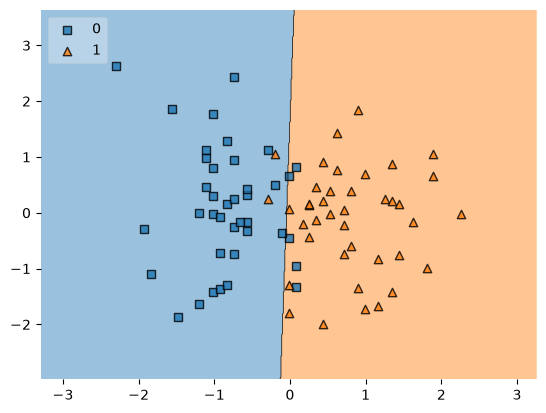

In [43]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [44]:
import pickle

In [46]:
pickle.dump(clf,open('model.pkl','wb'))